# Baseline: target = локальный минимум ±5

Все четыре индикатора оцениваются относительно локального минимума на горизонте 5 свежих публикаций ЦБ.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from fx_signal.baseline import build_baseline_frame

sns.set_theme(style='whitegrid')
HORIZON = 5
CONFIG = Path('../configs/baseline.yaml') if Path.cwd().name == 'notebooks' else Path('configs/baseline.yaml')
frame, metrics = build_baseline_frame(CONFIG, horizon=HORIZON)

## Покрытие и prevalence target

In [2]:
target_col = f'target_local_min_h{HORIZON}'
frame.groupby('currency')[target_col].agg(eligible='count', positives='sum', prevalence='mean')

,eligible,positives,prevalence
currency,,,
AMD,1878,106,0.056443
KGS,1878,108,0.057508
KZT,1878,105,0.055911
TJS,1878,104,0.055378
UZS,1878,106,0.056443


## Hit rate и lift каждого индикатора

In [3]:
metrics.sort_values(['corridor', 'lift'], ascending=[True, False]).reset_index(drop=True)

,horizon,corridor,indicator,eligible_days,signal_count,target_positives,signal_hit_rate,random_hit_rate,lift,signals_per_week
0,5,RUB->AMD,momentum,1794,251,101,0.223108,0.056299,3.962921,0.662519
1,5,RUB->AMD,level,1794,302,101,0.109272,0.056299,1.940922,0.797134
2,5,RUB->AMD,seasonality,1794,356,101,0.047753,0.056299,0.848203,0.939668
3,5,RUB->AMD,reversal,1794,87,101,0.000000,0.056299,0.000000,0.229638
4,5,RUB->KGS,momentum,1794,273,103,0.197802,0.057414,3.445215,0.720588
5,5,RUB->KGS,level,1794,361,103,0.099723,0.057414,1.736923,0.952866
6,5,RUB->KGS,seasonality,1794,384,103,0.052083,0.057414,0.907160,1.013575
7,5,RUB->KGS,reversal,1794,98,103,0.000000,0.057414,0.000000,0.258673
8,5,RUB->KZT,momentum,1794,249,101,0.212851,0.056299,3.780747,0.657240
9,5,RUB->KZT,level,1794,379,101,0.097625,0.056299,1.734058,1.000377


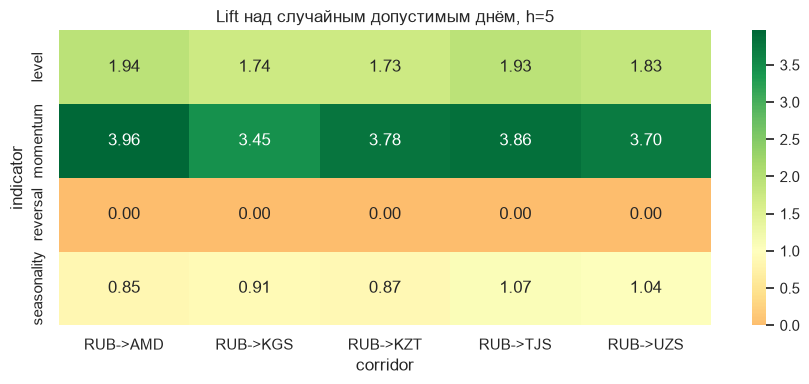

In [4]:
heatmap = metrics.pivot(index='indicator', columns='corridor', values='lift')
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heatmap, annot=True, fmt='.2f', center=1.0, cmap='RdYlGn', ax=ax)
ax.set_title(f'Lift над случайным допустимым днём, h={HORIZON}')
fig.tight_layout()
repo_root = CONFIG.resolve().parent.parent
figures_dir = repo_root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / f'baseline_lift_h{HORIZON}.png', dpi=160, bbox_inches='tight')

## Интерпретация

lift > 1 означает, что правило чаще случайного допустимого дня совпадает с выбранным local-min target. Reversal срабатывает после минимума, поэтому его низкий lift здесь нельзя считать окончательным выводом о полезности: для него нужна отдельная метрика последующего роста курса.